# Emissions-based decomposition

This reads `004_run_magicc_emissions_based.py`'s `fixed_`-prefixed per-species
output, i.e. base/counterfactual runs supplied emissions from 1751 and given the 
CH4/N2O "hardwired history" budget-closure re-anchoring wherever that gas isn't itself 
switched. Output files are prefixed `fixed_` to distinguish them from earlier outputs.

Consolidates `004`/`005`/`006` (NOx, redone under the corrected config - the version
previously committed reflected a stale default-config run, not the documented
CH4-only fix) + `013`/`017` (CO/VOC/CH4) + new work on N2O's Stratospheric Ozone
channel, 

Passes NOx, CO, VOC, CH4, and N2O counterfactuals into one delta-then-QEXTRA 
pipeline applied per (base scenario, species): compute each channel's ERF delta 
(baseline scenario minus its counterfactual from `004`), write it as a MAGICC 
`FILE_EXTRA_RF`  input, rerun MAGICC's climate module on each channel in isolation 
(QEXTRA) to get its GSAT  contribution, and check additivity against the channels' sum 
("Combined") and the leave-one-out GSAT delta ("Total").

## Imports

In [1]:
import logging
import os
import warnings
from pathlib import Path

import pandas as pd
from pandas_openscm.db import FeatherDataBackend, FeatherIndexBackend, OpenSCMDB

import attribution_common as ac

warnings.filterwarnings("ignore", message=".*Extending solar RF.*")
warnings.filterwarnings("ignore", message=".*magicc logged a WARNING message.*")
logging.getLogger("pymagicc").setLevel(logging.ERROR)

os.environ["MAGICC_EXECUTABLE_7"] = str(ac.MAGICC_EXECUTABLE_PATH)

In [2]:
SCENARIO_METADATA = {
    "vl": {"model": "REMIND-MAgPIE 3.5-4.11", "scenario": "SSP1 - Very Low Emissions", "version": 5},
    "ln": {"model": "AIM 3.0", "scenario": "SSP2 - Low Overshoot_a", "version": 23},
    "l": {"model": "MESSAGEix-GLOBIOM-GAINS 2.1-M-R12", "scenario": "SSP2 - Low Emissions", "version": 21},
    "ml": {"model": "COFFEE 1.6", "scenario": "SSP2 - Medium-Low Emissions", "version": 14},
    "m": {"model": "IMAGE 3.4", "scenario": "SSP2 - Medium Emissions", "version": 25},
    "hl": {"model": "WITCH 6.0", "scenario": "SSP5 - Medium-Low Emissions_a", "version": 32},
    "h": {"model": "GCAM 8s", "scenario": "SSP3 - High Emissions", "version": 3},
}
SCENARIO_LONG_TO_SHORT = {v["scenario"]: k for k, v in SCENARIO_METADATA.items()}

def scenario_short_name(base_scenario):
    """Human-readable short code for a long scenario name - for print/plot text only,
    never for constructing actual scenario-name keys (those still need the real long
    name to match what's in the data). Falls back to the long name itself if not found
    (e.g. "historical", or anything not in SCENARIO_METADATA)."""
    return SCENARIO_LONG_TO_SHORT.get(base_scenario, base_scenario)

## Configuration

In [3]:
EMBARGOED = True
"""Set True once running against real (embargoed) ScenarioMIP scenarios, so this
notebook's raw MAGICC-derived outputs are written under data/embargoed/ instead of
plain data/. Plots stay in plain data/plots/ regardless - see OUT_PLOTS_DIR below. Must
match 004's own EMBARGOED setting, since this notebook reads 004's per-species dbs."""
DATA_DIR = Path("../data/embargoed") if EMBARGOED else Path("../data")

BASE_SCENARIOS = ac.load_base_scenarios(DATA_DIR)
"""Auto-discovered from 001's base_scenarios.json manifest, same as 004 - must be a
subset of what 004 actually produced leave-one-out runs for."""

SWITCH_YEAR = 1750
"""Must match 004's SWITCH_YEAR - used to reconstruct each counterfactual's scenario
name (f"{base_scenario}_no_{species_key}_{SWITCH_YEAR}")."""

OUTPUT_PREFIX = "fixed_"
"""Prepended to every plot filename below."""

YEAR = 2100
REGION = ac.REGION

CORE_CATEGORIES = {
    "Tropospheric Ozone": "Effective Radiative Forcing|Tropospheric Ozone",
    "CH4": "Effective Radiative Forcing|CH4",
    "Stratospheric H2O": "Effective Radiative Forcing|CH4 Oxidation Stratospheric H2O",
}
HFC_CATEGORIES = {
    "F-Gases": "Effective Radiative Forcing|F-Gases",
    "Montreal Protocol Halogen Gases": "Effective Radiative Forcing|Montreal Protocol Halogen Gases",
}
N2O_CATEGORIES = {
    "N2O": "Effective Radiative Forcing|N2O",
    "Stratospheric Ozone": "Effective Radiative Forcing|Stratospheric Ozone",
}
AEROSOL_CATEGORIES = {
    "Aerosol Direct": "Effective Radiative Forcing|Aerosols|Direct Effect",
    "Aerosol Indirect": "Effective Radiative Forcing|Aerosols|Indirect Effect",
}
NOX_CATEGORIES = {
    **CORE_CATEGORIES,
    "N2O": "Effective Radiative Forcing|N2O",
    **AEROSOL_CATEGORIES,
}


def emissions_db_dir(species_key):
    """004's `fixed_`-prefixed dirs."""
    return DATA_DIR / f"fixed_emissions_scm_output_db_{ac.slugify(species_key)}"


SPECIES = {
    "NOx": {"db": emissions_db_dir("NOx"), "categories": NOX_CATEGORIES},
    "CO": {"db": emissions_db_dir("CO"), "categories": CORE_CATEGORIES},
    "VOC": {"db": emissions_db_dir("VOC"), "categories": CORE_CATEGORIES},
    "CH4": {"db": emissions_db_dir("CH4"), "categories": {**CORE_CATEGORIES, **HFC_CATEGORIES}},
    "N2O": {"db": emissions_db_dir("N2O"), "categories": N2O_CATEGORIES},
    # SOx/NH3 deliberately excluded - see 101/203: their marginal leave-one-out delta is
    # confounded by the NH3-nitrate competition mechanism and can come out net
    # wrong-signed. Use the burden-based analysis (102/105, or their fixed 202/205
    # counterparts) for these instead.
}
"""CH4's own contribution is just its own ERF delta - included as the "CH4" core
channel like any other species, since removing CH4 trivially changes CH4's own ERF by
the full delta. N2O's "Stratospheric Ozone" channel is new investigative work this
project never previously checked - see the diagnostic check below before trusting it."""

OUT_CHANNELS_DIR = DATA_DIR / "fixed_emissions_forcing_channels"
OUT_GSAT_DB_DIR = DATA_DIR / "fixed_emissions_channel_gsat_db"
"""fixed_-prefixed, not 104's own dirs - keeps this notebook's QEXTRA output separate
from 104's."""

OUT_PLOTS_DIR = Path("../data/plots")
"""Always plain data/plots/, regardless of EMBARGOED - plots and summary tables are not
considered sensitive, only raw emissions/MAGICC output (see species_interaction_overview.md
and this project's data-handling discussion)."""
OUT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MAX_PROCESSES = 5


def counterfactual_scenario_name(base_scenario, species_key):
    return f"{base_scenario}_no_{species_key}_{SWITCH_YEAR}"


def driving_scenario_name(base_scenario, species_key):
    """Unique per (base_scenario, species_key) - avoids collisions in the QEXTRA output
    scenario names (f"{driving_scenario_name}_forcing_only_{channel}") once BASE_SCENARIOS
    has more than one entry."""
    return f"{base_scenario}_{species_key}"

## N2O's Stratospheric Ozone channel: diagnostic check first

Never previously checked whether this channel is measurable via leave-one-out at all
(N2O is the dominant real-world stratospheric-ozone-depleting substance, but MAGICC's
attribution of this to N2O specifically was an open question). Check the raw ERF delta
trajectory for a wrong-signed transient (the same failure mode found for CH4's own
leave-one-out before the budget-closure fix) before trusting the channel below. Checked
against the first entry in BASE_SCENARIOS only - the mechanism being tested is a MAGICC
config property, not scenario-specific, so one check is representative.

In [4]:
BASE_SCENARIOS

['SSP1 - Very Low Emissions',
 'SSP2 - Low Emissions',
 'SSP2 - Low Overshoot_a',
 'SSP2 - Medium Emissions',
 'SSP2 - Medium-Low Emissions',
 'SSP3 - High Emissions',
 'SSP5 - Medium-Low Emissions_a']

In [5]:
n2o_check_scenario = BASE_SCENARIOS[5]
n2o_output = OpenSCMDB(
    backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=SPECIES["N2O"]["db"]
).load(out_columns_type=int)
n2o_output.columns.name = "year"

strat_ozone_delta = ac.compute_delta(
    n2o_output,
    n2o_check_scenario,
    counterfactual_scenario_name(n2o_check_scenario, "N2O"),
    N2O_CATEGORIES["Stratospheric Ozone"],
)
print(f"N2O -> Stratospheric Ozone ERF delta ({n2o_check_scenario}, mean, W/m^2), by year:")
for y in [1800, 1850, 1900, 1950, 2000, 2023, 2050, 2100]:
    if y in strat_ozone_delta.columns:
        print(f"  {y}: {strat_ozone_delta[y].mean():+.5f}")

N2O -> Stratospheric Ozone ERF delta (SSP3 - High Emissions, mean, W/m^2), by year:
  1800: +0.00000
  1850: +0.00000
  1900: +0.00000
  1950: +0.00000
  2000: +0.00000
  2023: +0.00053
  2050: +0.00050
  2100: +0.00000


If the trace above is monotonic and consistently signed from the switch year onward
(no sign flip partway through), the channel is trustworthy and included below as-is.
If it shows a wrong-signed transient like CH4's did, treat N2O as single-total-only
and flag this section as inconclusive - update SPECIES["N2O"]["categories"] to drop
"Stratospheric Ozone" (leaving just {"N2O": ...}) before rerunning if so.

## Process each (base scenario, species): compute deltas, run QEXTRA

In [6]:
def process_species(base_scenario, species_key, spec):
    counterfactual = counterfactual_scenario_name(base_scenario, species_key)
    label = driving_scenario_name(base_scenario, species_key)

    df = OpenSCMDB(backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=spec["db"]).load(
        out_columns_type=int
    )
    df.columns.name = "year"

    deltas = {
        channel: ac.compute_delta(df, base_scenario, counterfactual, variable, region=REGION)
        for channel, variable in spec["categories"].items()
    }

    climate_models_cfgs = ac.load_magicc_cfgs()
    n_members = next(iter(deltas.values())).shape[0]
    climate_models_cfgs["MAGICC7"] = climate_models_cfgs["MAGICC7"][:n_members]

    ac.run_qextra_channels(
        scenarios_osr=df,
        driving_scenario_name=label,
        emissions_source_scenario=base_scenario,
        channel_series=deltas,
        combined_label="Combined",
        climate_models_cfgs=climate_models_cfgs,
        forcing_files_dir=OUT_CHANNELS_DIR / ac.slugify(label),
        out_db_dir=OUT_GSAT_DB_DIR,
        max_processes=MAX_PROCESSES,
    )

    print(f"--- {label} ({YEAR}) ERF deltas (mean, W/m^2) ---")
    print(pd.Series({channel: d[YEAR].mean() for channel, d in deltas.items()}))
    print()
    return df, list(deltas.keys())

In [7]:
species_data = {
    (base_scenario, species_key): process_species(base_scenario, species_key, spec)
    for base_scenario in BASE_SCENARIOS
    for species_key, spec in SPECIES.items()
}

/Users/hoegner/GitHub/species-attribution/.venv/lib/python3.13/site-packages/scmdata/database/_database.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  import tqdm.autonotebook as tqdman


Climate models:   0%|          | 0/1 [00:00<?, ?it/s]

Scenario batch:   0%|          | 0/1 [00:00<?, ?it/s]

Climate models:   0%|          | 0.00/1.00 [00:00<?, ?it/s]

Historical data has not been checked


...

Scenario batch: 100%|██████████| 1/1 [00:52<00:00, 52.04s/it]

Scenario batch: 100%|██████████| 1/1 [00:52<00:00, 52.04s/it]


Climate models: 100%|██████████| 1/1 [00:52<00:00, 52.04s/it]

Climate models: 100%|██████████| 1/1 [00:52<00:00, 52.04s/it]

--- SSP5 - Medium-Low Emissions_a_N2O (2100) ERF deltas (mean, W/m^2) ---
N2O                    0.386141
Stratospheric Ozone    0.000000
dtype: float64



## Summarize: per-channel GSAT contribution, additivity, % of total explained

=== SSP1 - Very Low Emissions_NOx (2050) ===
Tropospheric Ozone    0.030846
CH4                  -0.047530
Stratospheric H2O    -0.004924
N2O                   0.000704
Aerosol Direct       -0.010624
Aerosol Indirect      0.104867
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum of parts - Combined), per member:
mean      0.000868
median    0.000538
std       0.001068
p5        0.000055
p17       0.000178
p83       0.001427
p95       0.002825
dtype: float64

Total SSP1 - Very Low Emissions_NOx GSAT effect (per-member paired diff, full emissions-driven run):
mean      0.064325
median    0.054378
std       0.064127
p5       -0.022030
p17       0.003270
p83       0.123354
p95       0.181761
dtype: float64
These channels explain 112.7% (mean-based) of that total
NOTE: NOx's own total effect is small and its sign is not well-established (5-95% range [-0.022, +0.182] K spans zero) - report as such, not as a confident point estimate.



=== SSP1 - Very Low Emissions_CO (2050) ===
Tropospheric Ozone    0.014160
CH4                   0.004727
Stratospheric H2O     0.000487
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum of parts - Combined), per member:
mean      2.278713e-06
median   -3.335381e-07
std       1.534721e-05
p5       -1.475417e-05
p17      -7.927485e-06
p83       1.103822e-05
p95       2.551653e-05
dtype: float64

Total SSP1 - Very Low Emissions_CO GSAT effect (per-member paired diff, full emissions-driven run):
mean      0.020393
median    0.019197
std       0.007648
p5        0.010738
p17       0.013995
p83       0.026436
p95       0.034355
dtype: float64
These channels explain 95.0% (mean-based) of that total

=== SSP1 - Very Low Emissions_VOC (2050) ===
Tropospheric Ozone    0.019127
CH4                   0.007508
Stratospheric H2O     0.000777
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum of parts - Combined), per member:
mean     -0.000015
median

=== SSP1 - Very Low Emissions_CH4 (2050) ===
Tropospheric Ozone                 0.091317
CH4                                0.282495
Stratospheric H2O                  0.028908
F-Gases                            0.003278
Montreal Protocol Halogen Gases    0.005816
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum of parts - Combined), per member:
mean     -0.003865
median   -0.003041
std       0.003481
p5       -0.009381
p17      -0.005881
p83      -0.001513
p95      -0.000796
dtype: float64

Total SSP1 - Very Low Emissions_CH4 GSAT effect (per-member paired diff, full emissions-driven run):
mean      0.471707
median    0.455100
std       0.111335
p5        0.320426
p17       0.373462
p83       0.568020
p95       0.665380
dtype: float64
These channels explain 88.1% (mean-based) of that total

=== SSP1 - Very Low Emissions_N2O (2050) ===
N2O                    0.132820
Stratospheric Ozone    0.000238
Name: GSAT contribution mean (K), dtype: float64

Additivity r

=== SSP2 - Low Emissions_NOx (2050) ===
Tropospheric Ozone    0.065107
CH4                  -0.061603
Stratospheric H2O    -0.006397
N2O                   0.000998
Aerosol Direct       -0.023167
Aerosol Indirect      0.047232
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum of parts - Combined), per member:
mean      0.000584
median    0.000401
std       0.000596
p5        0.000108
p17       0.000202
p83       0.000922
p95       0.001734
dtype: float64

Total SSP2 - Low Emissions_NOx GSAT effect (per-member paired diff, full emissions-driven run):
mean      0.004892
median    0.001446
std       0.040593
p5       -0.055531
p17      -0.030657
p83       0.037935
p95       0.074996
dtype: float64
These channels explain 441.2% (mean-based) of that total
NOTE: NOx's own total effect is small and its sign is not well-established (5-95% range [-0.056, +0.075] K spans zero) - report as such, not as a confident point estimate.

=== SSP2 - Low Emissions_CO (2050) ===
Tro

=== SSP2 - Low Emissions_VOC (2050) ===
Tropospheric Ozone    0.019976
CH4                   0.007259
Stratospheric H2O     0.000751
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum of parts - Combined), per member:
mean     -0.000016
median   -0.000013
std       0.000013
p5       -0.000041
p17      -0.000024
p83      -0.000006
p95      -0.000003
dtype: float64

Total SSP2 - Low Emissions_VOC GSAT effect (per-member paired diff, full emissions-driven run):
mean      0.031648
median    0.030751
std       0.009033
p5        0.019099
p17       0.023875
p83       0.039059
p95       0.047225
dtype: float64
These channels explain 88.5% (mean-based) of that total

=== SSP2 - Low Emissions_CH4 (2050) ===
Tropospheric Ozone                 0.101953
CH4                                0.317556
Stratospheric H2O                  0.032410
F-Gases                            0.004749
Montreal Protocol Halogen Gases    0.006054
Name: GSAT contribution mean (K), dtype: float64

...

/Users/hoegner/GitHub/species-attribution/notebooks/attribution_common.py:657: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=COLOR_SURFACE)


=== SSP2 - Medium-Low Emissions_CO (2050) ===
Tropospheric Ozone    0.024808
CH4                   0.006283
Stratospheric H2O     0.000649
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum of parts - Combined), per member:
mean     -0.000010
median   -0.000008
std       0.000015
p5       -0.000035
p17      -0.000020
p83      -0.000001
p95       0.000008
dtype: float64

Total SSP2 - Medium-Low Emissions_CO GSAT effect (per-member paired diff, full emissions-driven run):
mean      0.034562
median    0.033182
std       0.011364
p5        0.019204
p17       0.024927
p83       0.043725
p95       0.055520
dtype: float64
These channels explain 91.9% (mean-based) of that total

=== SSP2 - Medium-Low Emissions_VOC (2050) ===
Tropospheric Ozone    0.023652
CH4                   0.007941
Stratospheric H2O     0.000822
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum of parts - Combined), per member:
mean     -0.000024
median   -0.000019
std      

=== SSP2 - Medium-Low Emissions_N2O (2050) ===
N2O                    0.142923
Stratospheric Ozone    0.000239
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum of parts - Combined), per member:
mean     -5.472367e-06
median   -3.565340e-06
std       6.720372e-06
p5       -1.618625e-05
p17      -8.943100e-06
p83      -1.001166e-06
p95      -2.875119e-07
dtype: float64

Total SSP2 - Medium-Low Emissions_N2O GSAT effect (per-member paired diff, full emissions-driven run):
mean      0.186790
median    0.182321
std       0.038345
p5        0.132765
p17       0.152720
p83       0.218658
p95       0.254547
dtype: float64
These channels explain 76.6% (mean-based) of that total

=== SSP3 - High Emissions_NOx (2050) ===
Tropospheric Ozone    0.057206
CH4                  -0.050752
Stratospheric H2O    -0.005264
N2O                   0.000862
Aerosol Direct       -0.021601
Aerosol Indirect      0.054919
Name: GSAT contribution mean (K), dtype: float64

Additivity residua

=== SSP3 - High Emissions_CH4 (2050) ===
Tropospheric Ozone                 0.115956
CH4                                0.379028
Stratospheric H2O                  0.038497
F-Gases                            0.007436
Montreal Protocol Halogen Gases    0.006884
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum of parts - Combined), per member:
mean     -0.008772
median   -0.006769
std       0.007392
p5       -0.023171
p17      -0.013283
p83      -0.003171
p95      -0.001761
dtype: float64

Total SSP3 - High Emissions_CH4 GSAT effect (per-member paired diff, full emissions-driven run):
mean      0.625345
median    0.608456
std       0.134961
p5        0.433979
p17       0.505810
p83       0.744378
p95       0.862817
dtype: float64
These channels explain 89.0% (mean-based) of that total

=== SSP3 - High Emissions_N2O (2050) ===
N2O                    0.145673
Stratospheric Ozone    0.000258
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum

=== SSP5 - Medium-Low Emissions_a_VOC (2050) ===
Tropospheric Ozone    0.021392
CH4                   0.007030
Stratospheric H2O     0.000727
Name: GSAT contribution mean (K), dtype: float64

Additivity residual (sum of parts - Combined), per member:
mean     -0.000017
median   -0.000014
std       0.000014
p5       -0.000044
p17      -0.000025
p83      -0.000007
p95      -0.000004
dtype: float64

Total SSP5 - Medium-Low Emissions_a_VOC GSAT effect (per-member paired diff, full emissions-driven run):
mean      0.033195
median    0.032221
std       0.009266
p5        0.019839
p17       0.025002
p83       0.040758
p95       0.049034
dtype: float64
These channels explain 87.9% (mean-based) of that total

=== SSP5 - Medium-Low Emissions_a_CH4 (2050) ===
Tropospheric Ozone                 0.123417
CH4                                0.406076
Stratospheric H2O                  0.041140
F-Gases                            0.007367
Montreal Protocol Halogen Gases    0.007006
Name: GSAT contributi

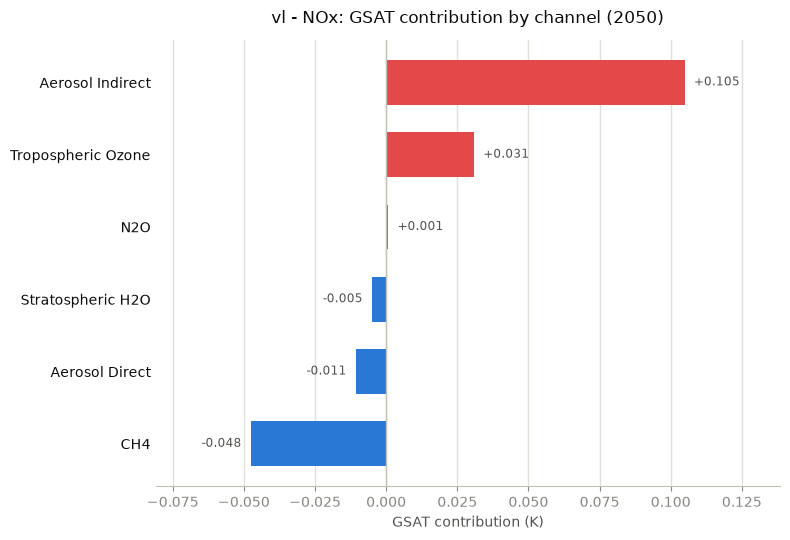

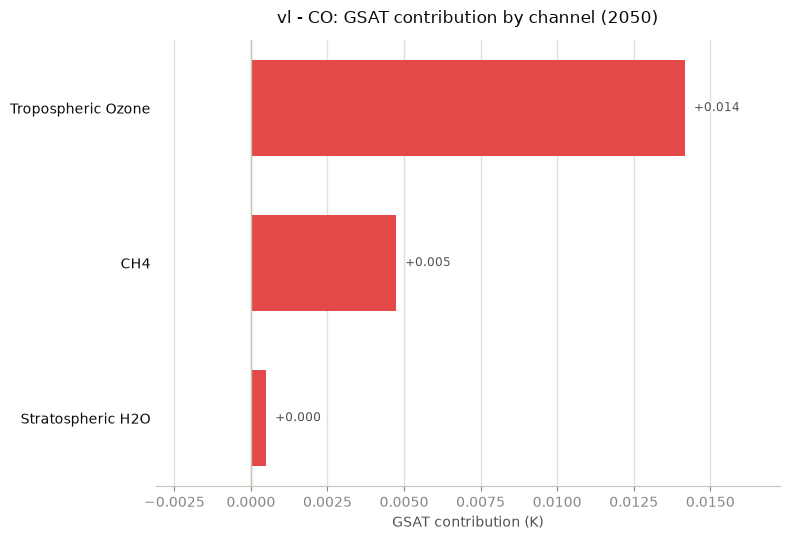

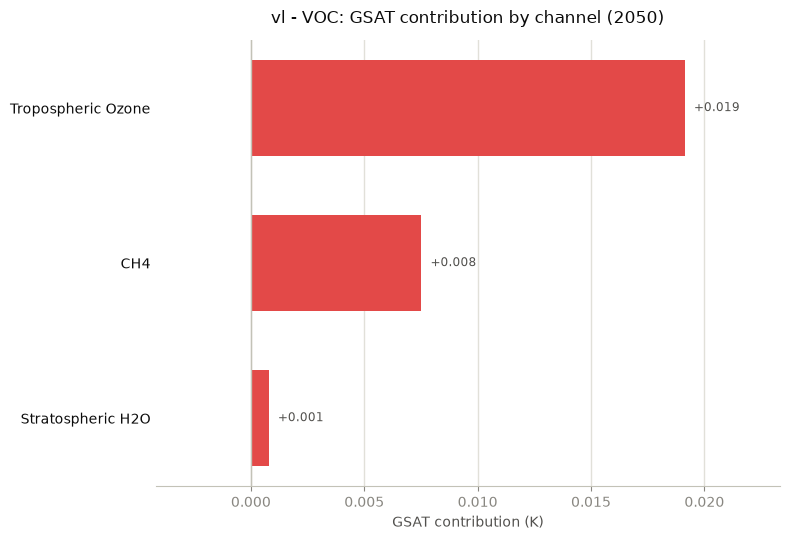

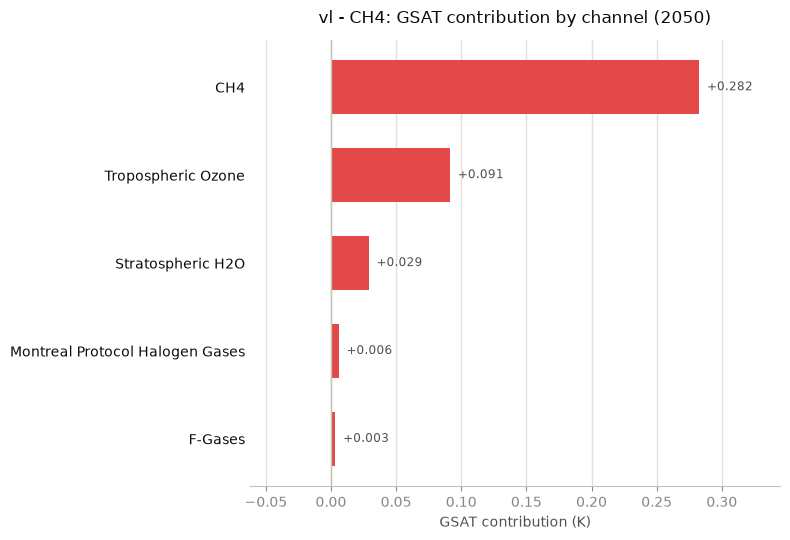

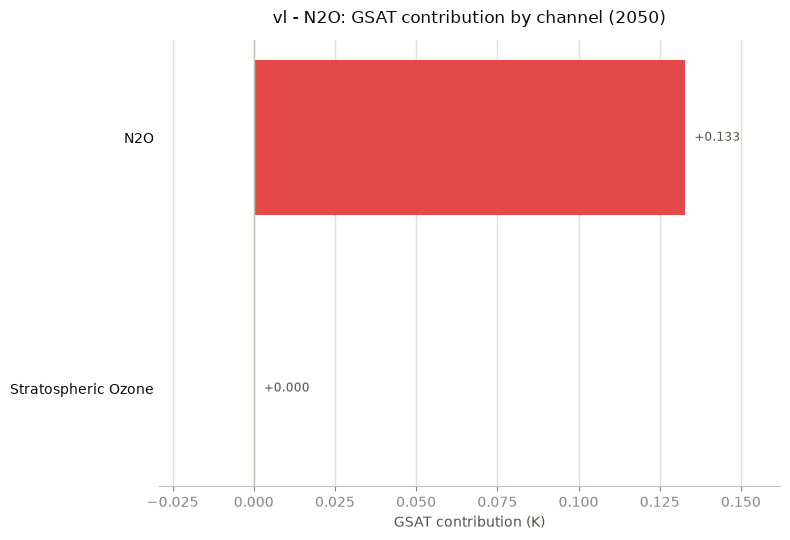

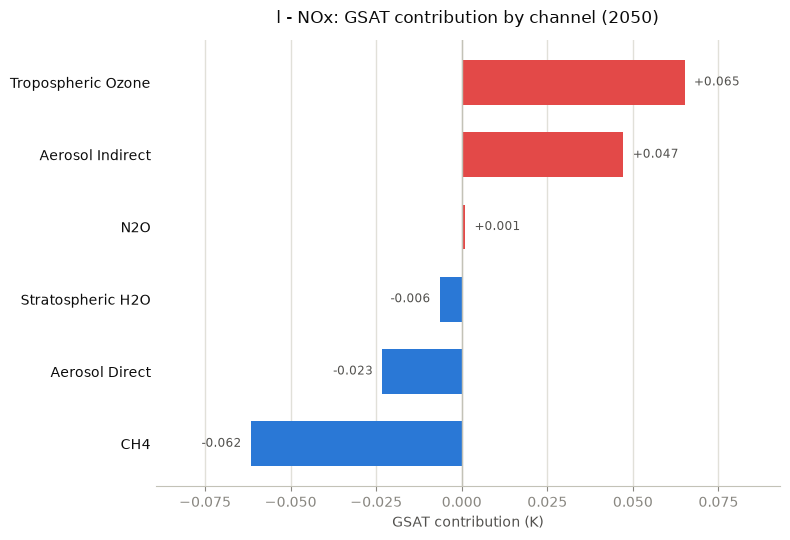

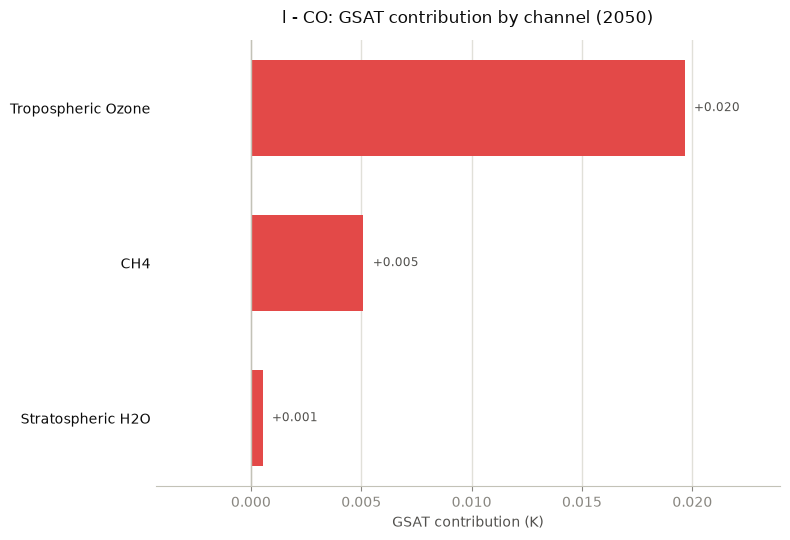

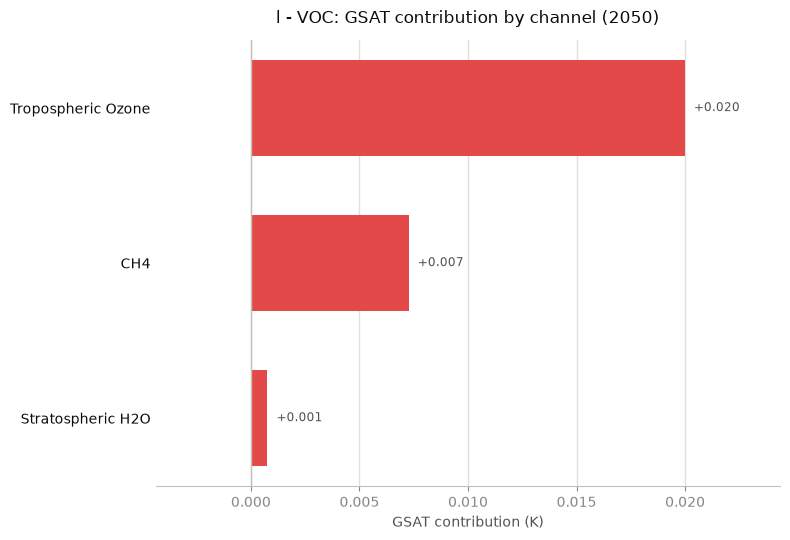

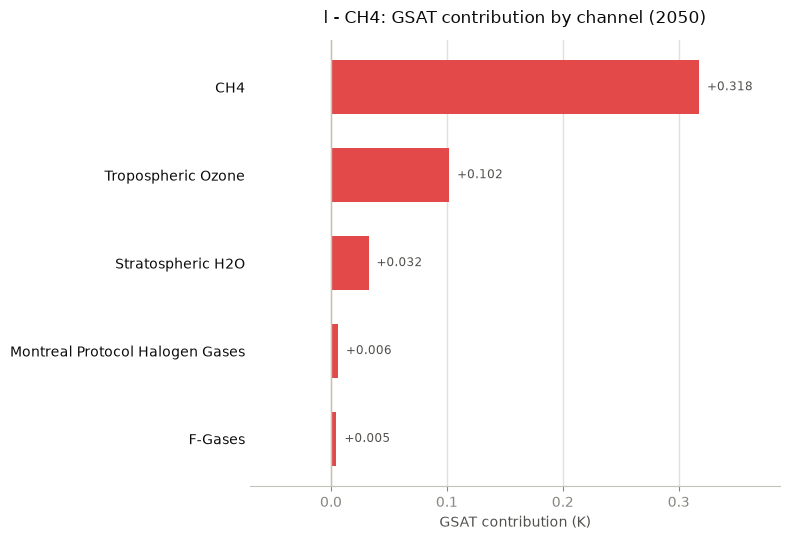

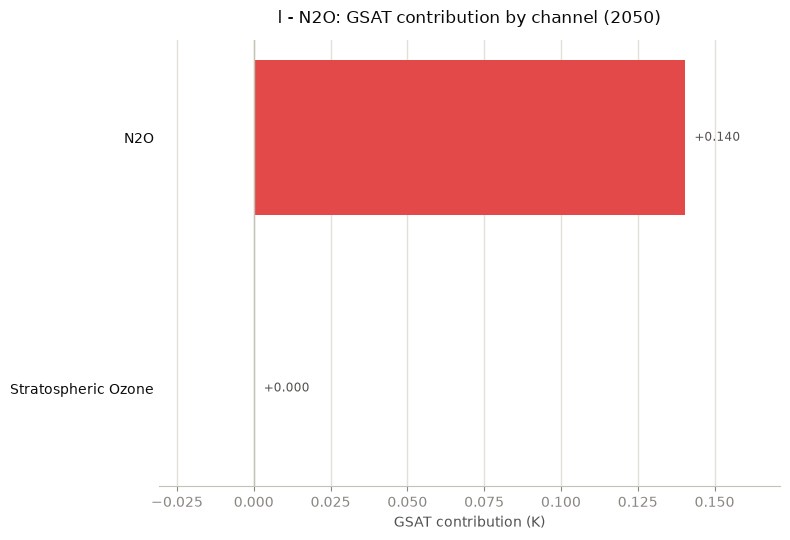

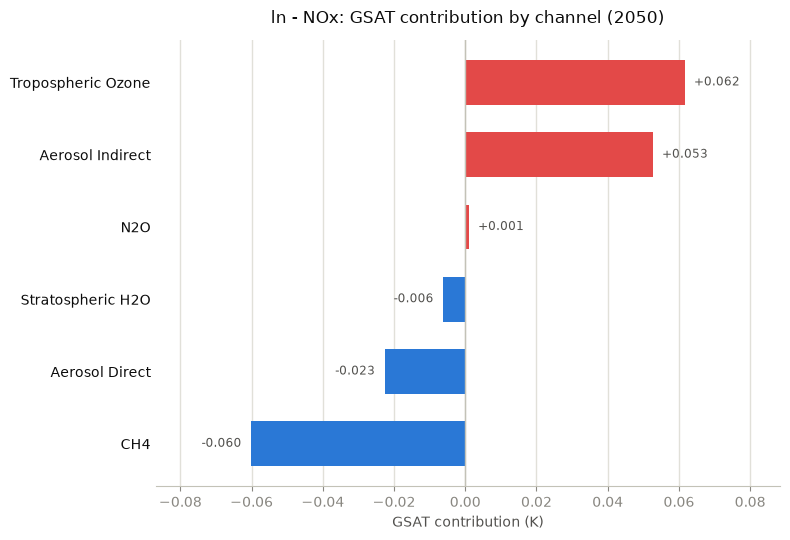

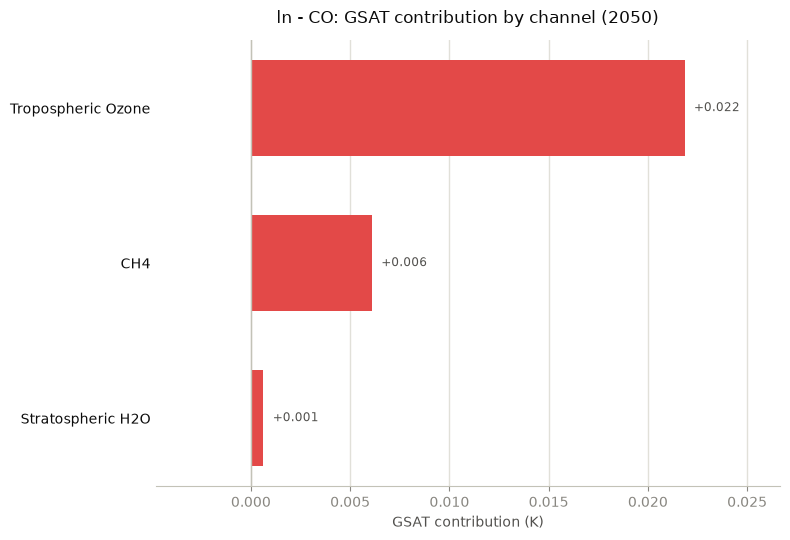

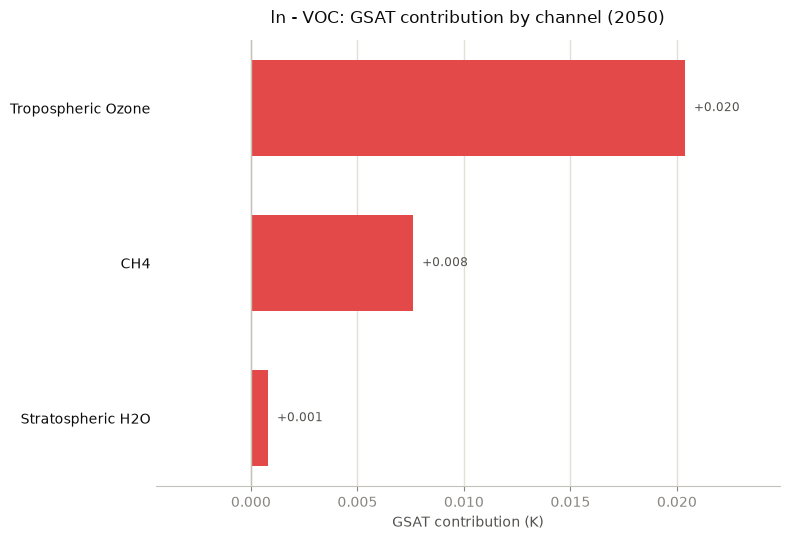

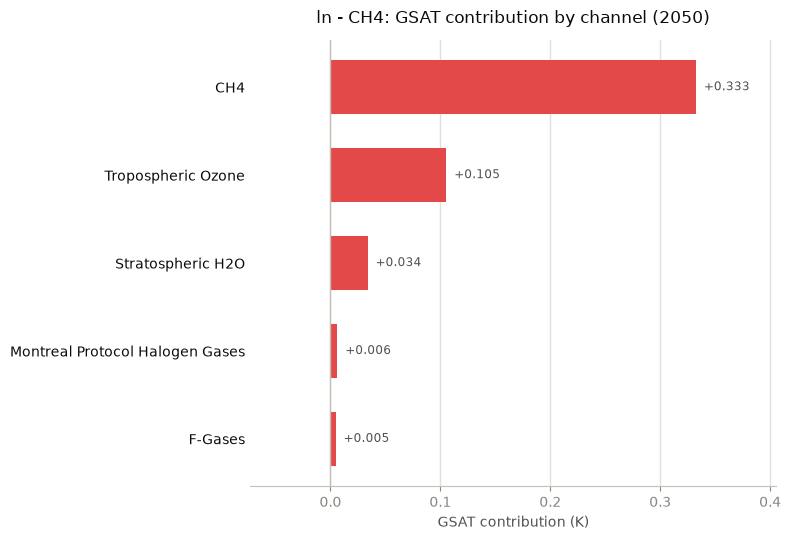

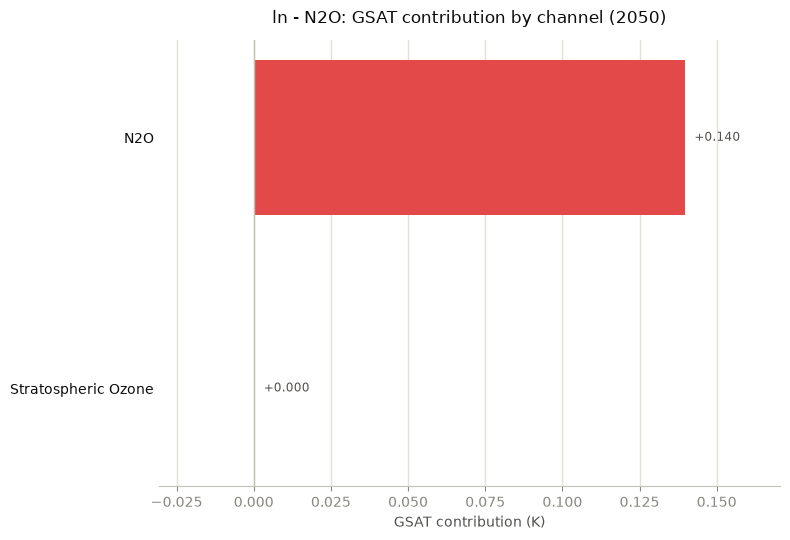

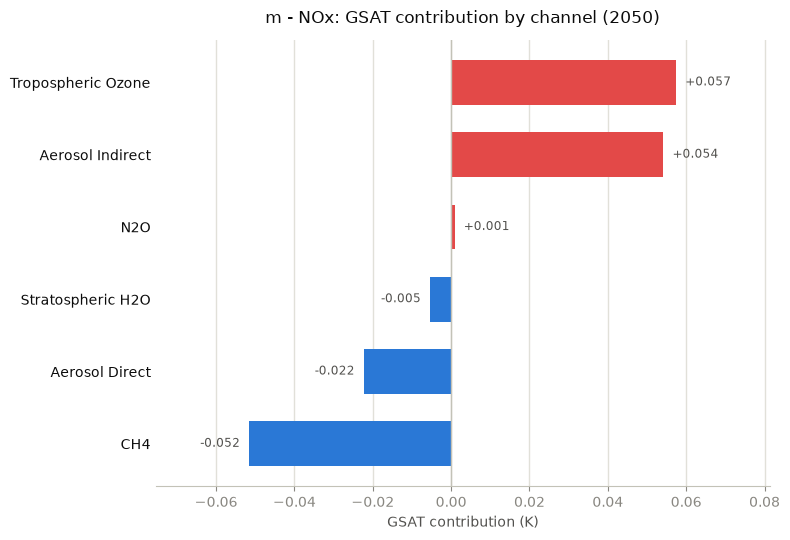

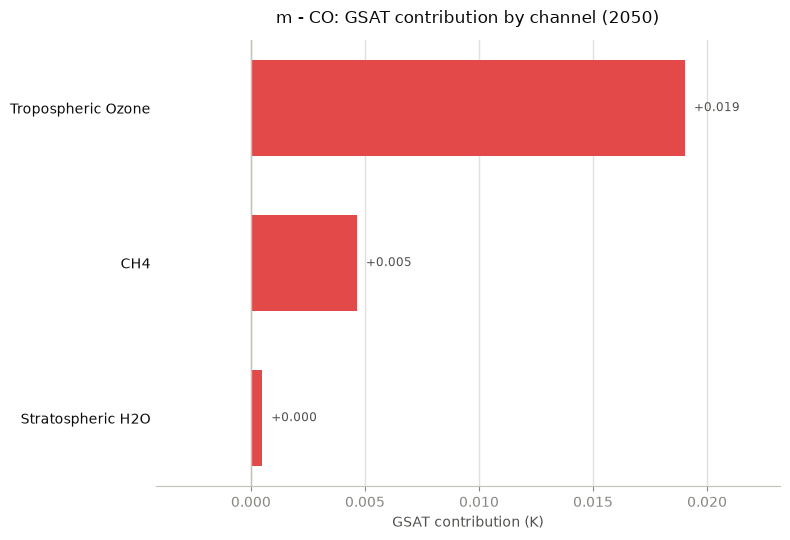

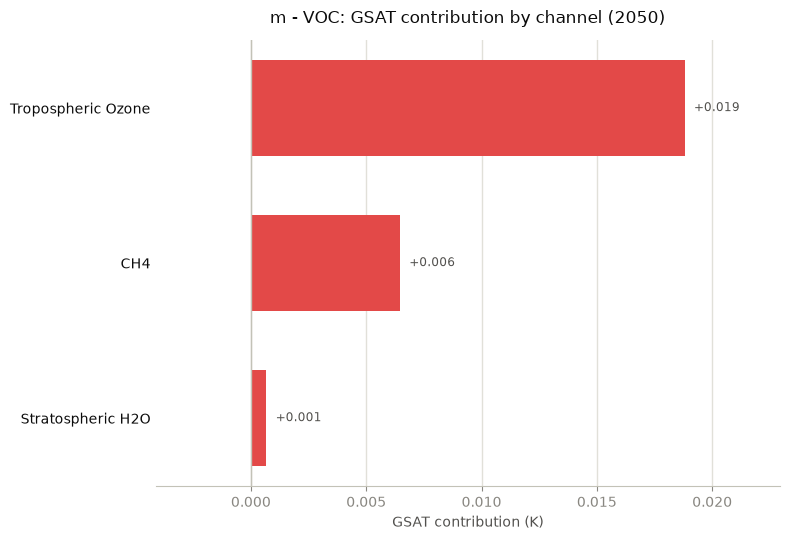

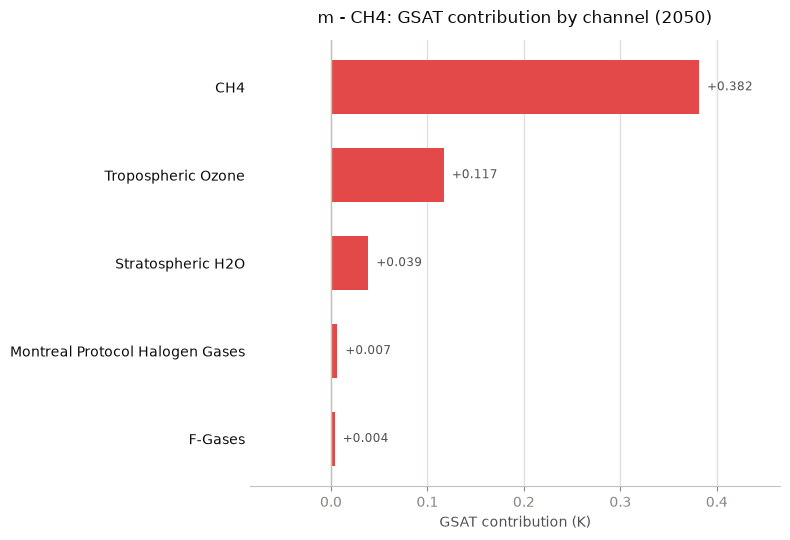

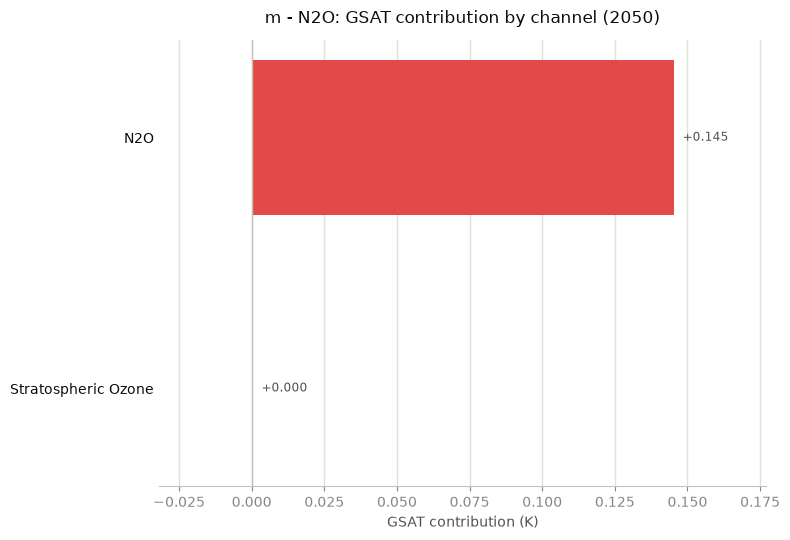

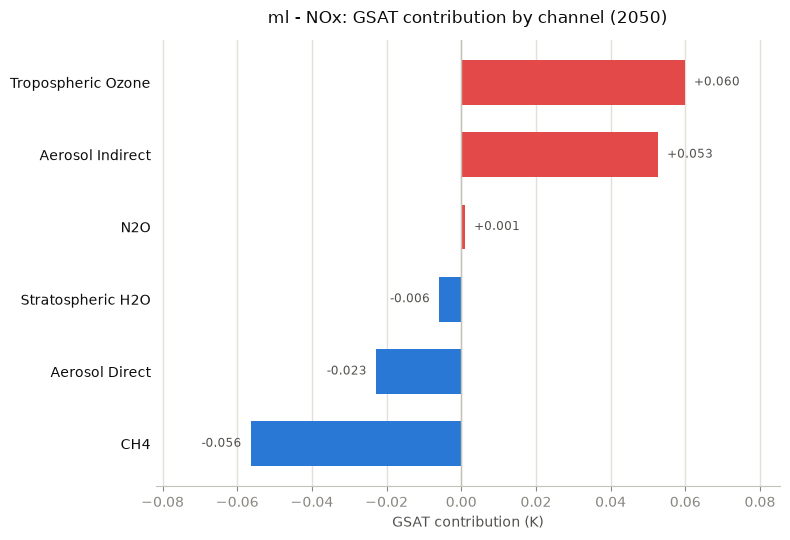

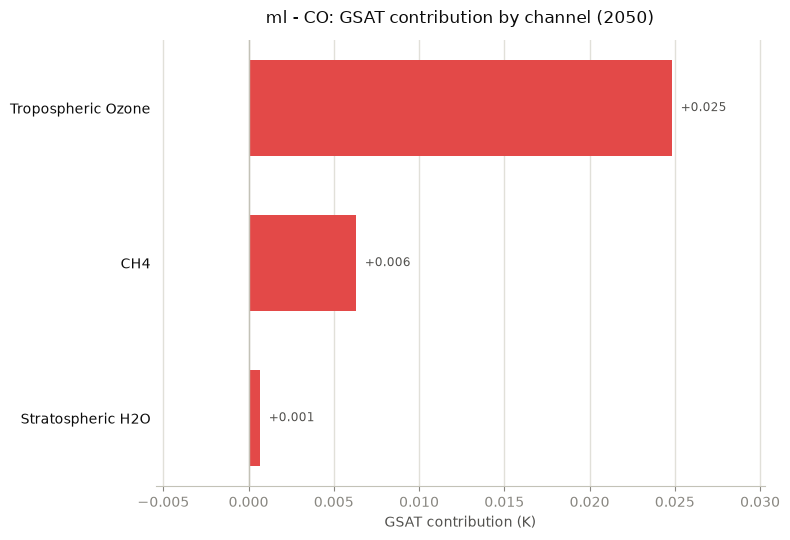

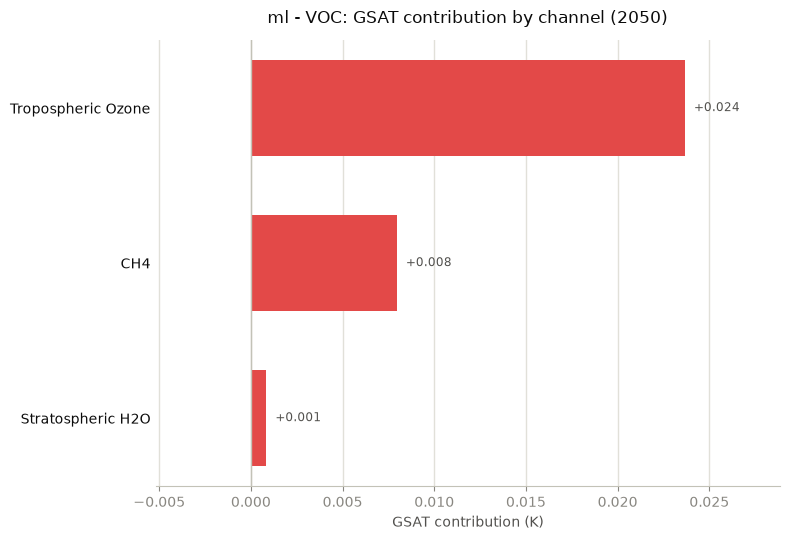

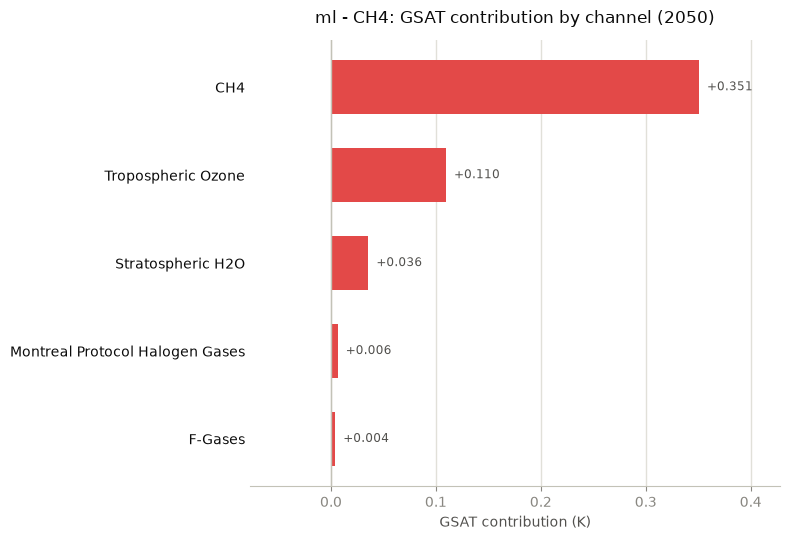

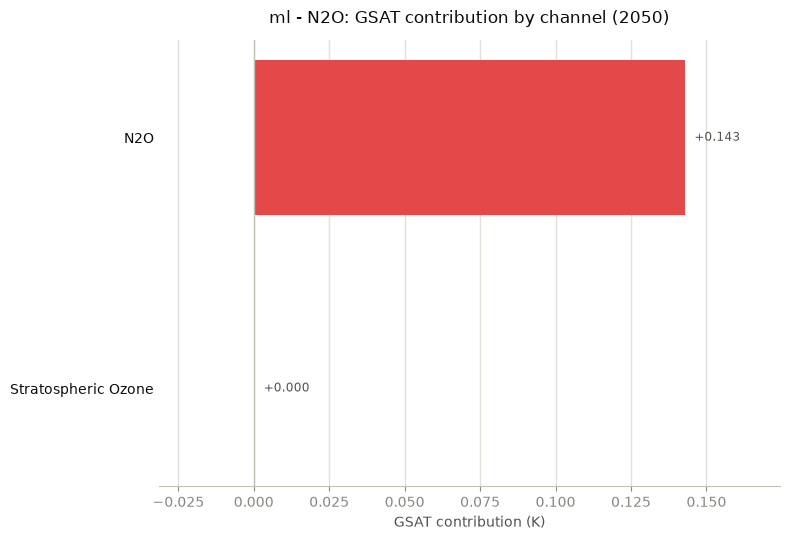

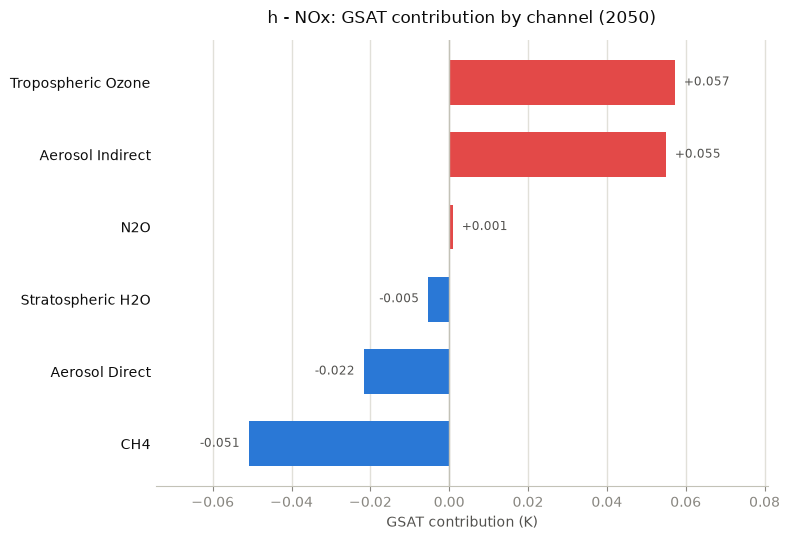

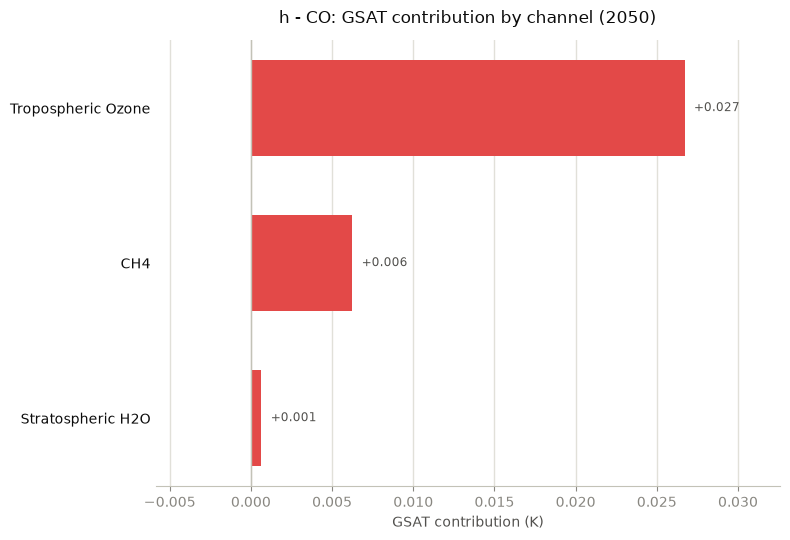

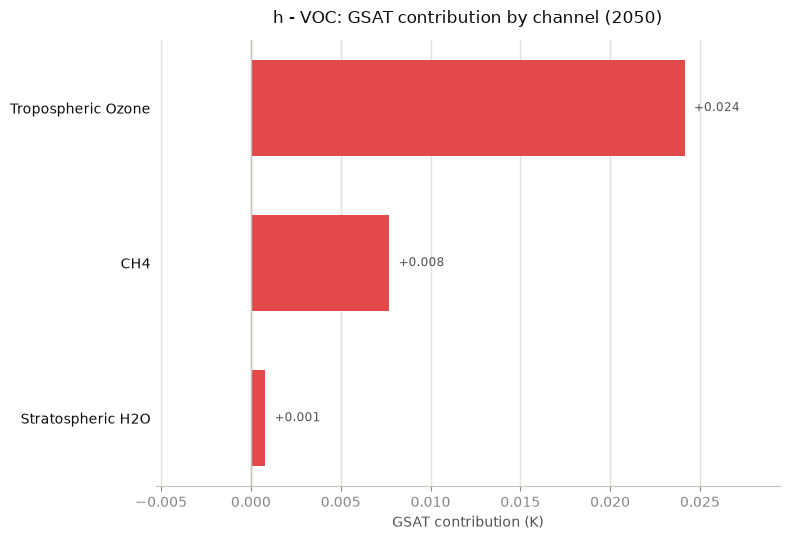

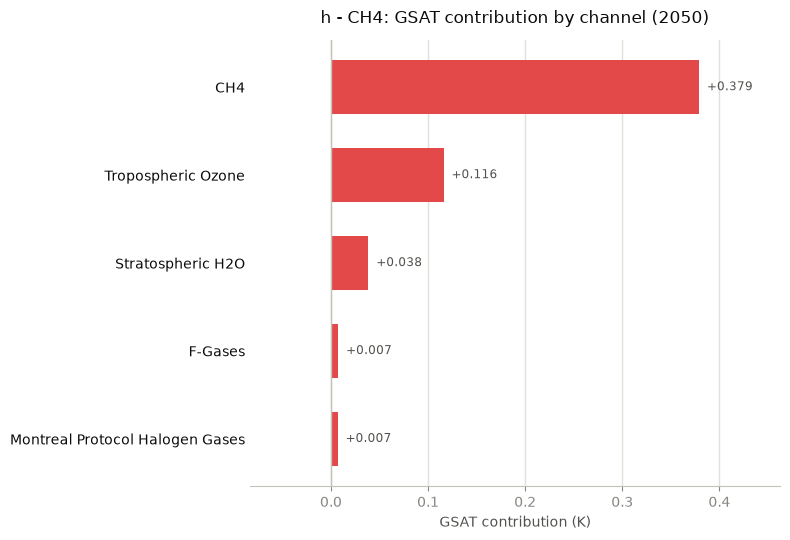

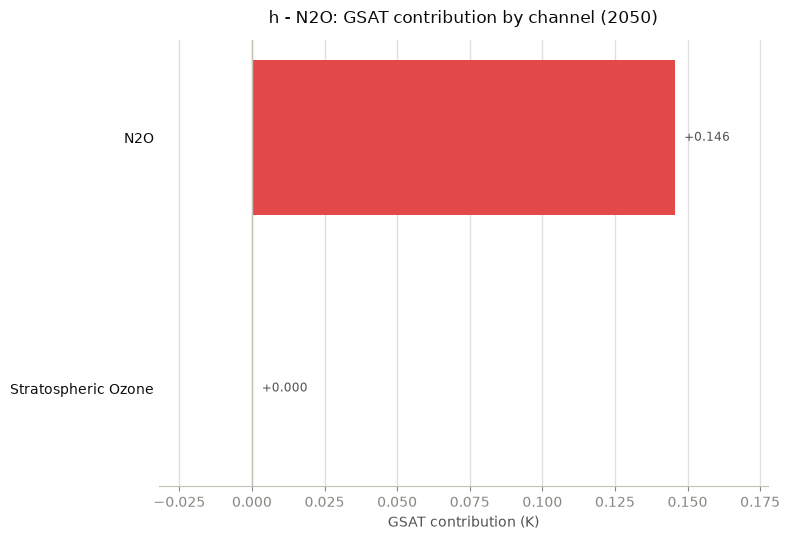

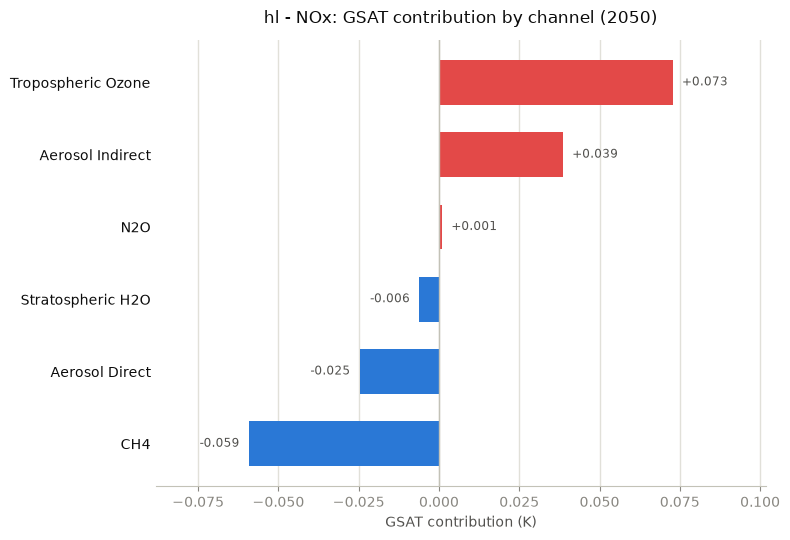

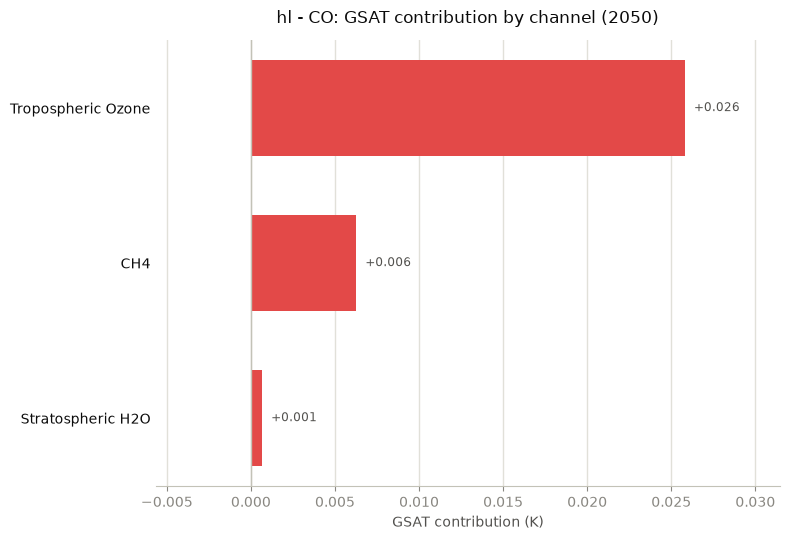

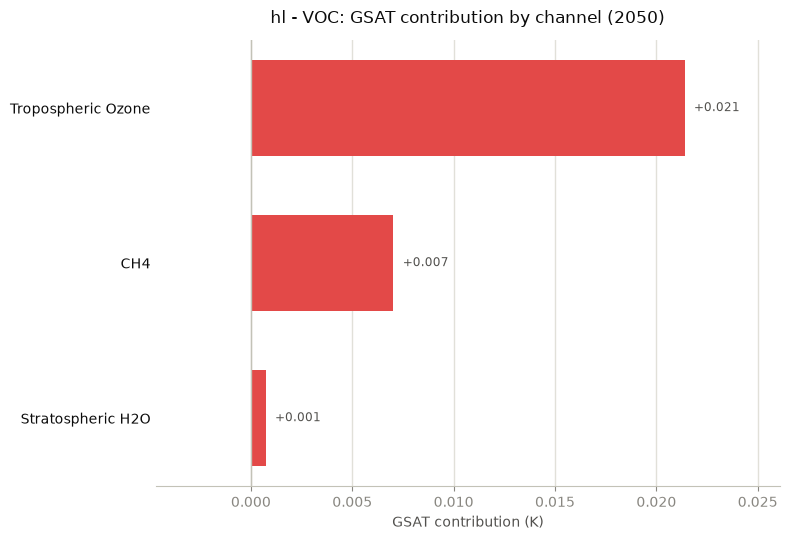

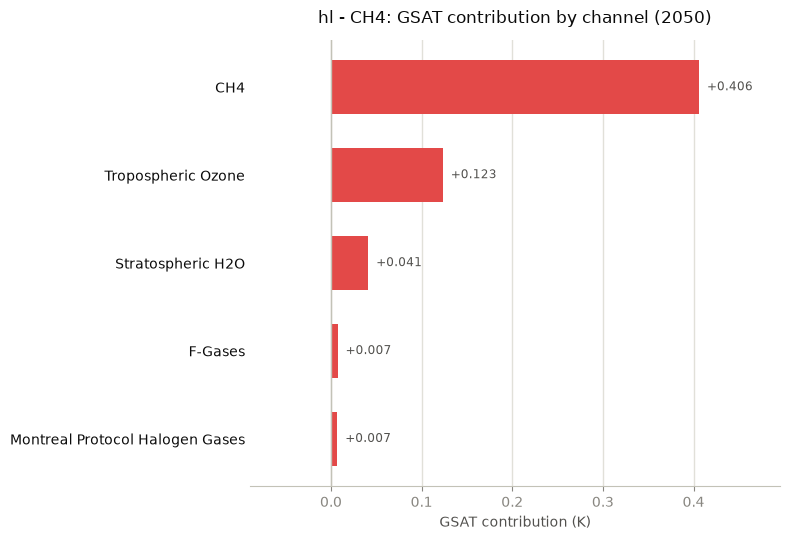

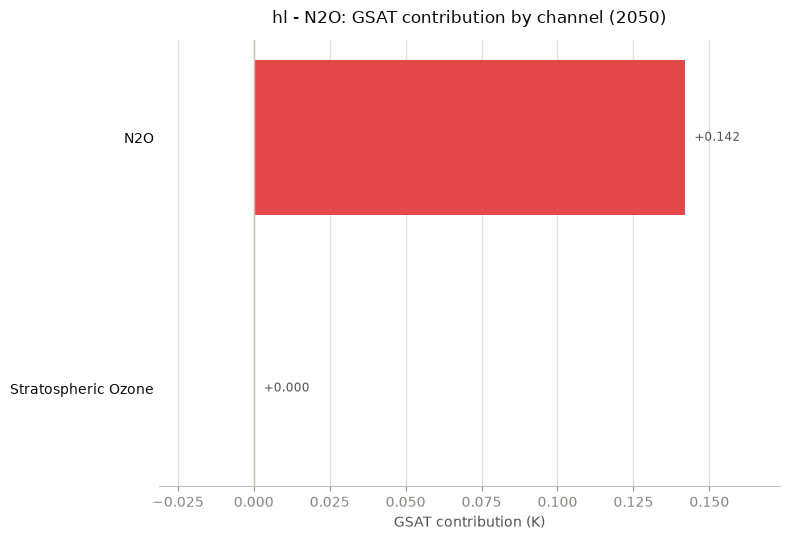

In [8]:
YEAR = 2050

qextra_result = OpenSCMDB(
    backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=OUT_GSAT_DB_DIR
).load(out_columns_type=int)
qextra_result.columns.name = "year"
qextra_gsat = qextra_result.loc[qextra_result.index.get_level_values("variable") == "Surface Air Temperature Change"]


def channel_series(label, channel):
    scenario = f"{label}_forcing_only_{channel}"
    mask = qextra_gsat.index.get_level_values("scenario") == scenario
    return ac.member_series(qextra_gsat.loc[mask], YEAR)


summary_tables = {}
for base_scenario in BASE_SCENARIOS:
    for species_key, spec in SPECIES.items():
        label = driving_scenario_name(base_scenario, species_key)
        counterfactual = counterfactual_scenario_name(base_scenario, species_key)
        base_df, channels_written = species_data[(base_scenario, species_key)]
        channels = [c for c in channels_written if c != "Combined"]
        contribution_series = {c: channel_series(label, c) for c in channels}
        combined_series = channel_series(label, "Combined")

        total_base = ac.load_erf(base_df, base_scenario, "Surface Air Temperature Change", region=REGION)
        total_counterfactual = ac.load_erf(base_df, counterfactual, "Surface Air Temperature Change", region=REGION)
        common = total_base.index.intersection(total_counterfactual.index)
        total_series = total_base.loc[common][YEAR] - total_counterfactual.loc[common][YEAR]

        summary = pd.Series({c: s.mean() for c, s in contribution_series.items()}, name="GSAT contribution mean (K)")
        sum_of_parts = sum(contribution_series.values())
        additivity_residual = sum_of_parts - combined_series
        combined_stats = ac.distribution_summary(combined_series)
        total_stats = ac.distribution_summary(total_series)
        summary_tables[(base_scenario, species_key)] = summary

        print(f"=== {label} ({YEAR}) ===")
        print(summary)
        print()
        print("Additivity residual (sum of parts - Combined), per member:")
        print(ac.distribution_summary(additivity_residual))
        print()
        print(f"Total {label} GSAT effect (per-member paired diff, full emissions-driven run):")
        print(total_stats)
        if abs(total_stats["mean"]) > 1e-6:
            print(f"These channels explain {combined_stats['mean'] / total_stats['mean'] * 100:.1f}% (mean-based) of that total")
        if species_key == "NOx":
            print(
                "NOTE: NOx's own total effect is small and its sign is not well-established "
                f"(5-95% range [{total_stats['p5']:+.3f}, {total_stats['p95']:+.3f}] K spans zero) - "
                "report as such, not as a confident point estimate."
            )
        print()